# Exploratory Data Analysis

This file consists of exploratory data analysis of our dataset downloded from kaggle and from a Reserach Paper.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

### 1. Create Dataframe
Here we are reading the cleaned csv and creating Dataframe

In [15]:
df = pd.read_csv("../data/raw/news_rp.csv", encoding="latin-1")
df.head()

,title,label
0,its no show for cinepolis now the indian expre...,2
1,James Corden seducing Jamie Dornan Fifty Shade...,1
2,SARAH PALINS SON BREAKS Into Family Home Savag...,0
3,Brad Pitt moves in with Kate Hudson,0
4,man removed from flight after allegedly harass...,2


### 2. Explore Data
Here we are exploring the dataset.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155121 entries, 0 to 155120
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   title   155108 non-null  str  
 1   label   155121 non-null  int64
dtypes: int64(1), str(1)
memory usage: 19.0 MB


In [17]:
df.shape

(155121, 2)

In [18]:
df.describe()

,label
count,155121.000000
mean,1.316327
std,0.787617
min,0.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,2.000000


In [6]:
df.columns

Index(['title', 'label'], dtype='str')

In [19]:
df["label"].value_counts()

label
2    80409
1    43372
0    31340
Name: count, dtype: int64

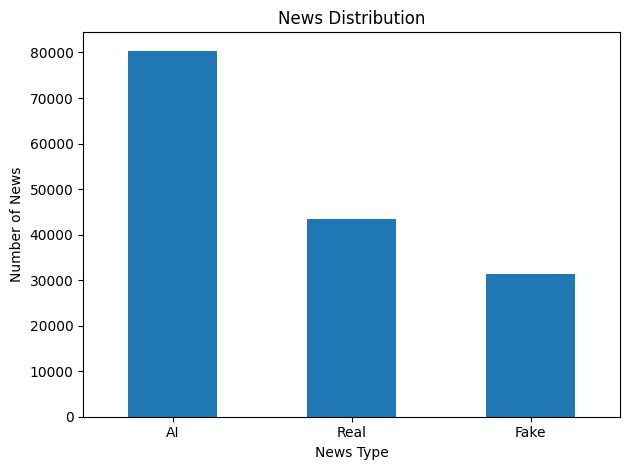

In [ ]:
def get_plot(df):
    counts = df["label"].value_counts().reindex([2, 1, 0])

    counts.plot(kind="bar")
    plt.xlabel("News Type")
    plt.ylabel("Number of News")
    plt.title("News Distribution")
    plt.xticks([0, 1, 2], ["AI", "Real", "Fake"], rotation=0)
    
    plt.tight_layout()
    plt.savefig("../figures/news_distribution_balanced.png", dpi=300, bbox_inches="tight")
    
    plt.show()
    
get_plot(df)

In [11]:
import pandas as pd

# Downsample AI class to 40,000 samples
ai = df[df["label"] == 2].sample(n=31000, random_state=42)
real = df[df["label"] == 1].sample(n=31000, random_state=42)
fake = df[df["label"] == 0].sample(n=31000, random_state=42)

# Combine them
df_balanced = pd.concat([ai, real, fake], ignore_index=True)

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the new class distribution
print(df_balanced["label"].value_counts())

label
2    31000
0    31000
1    31000
Name: count, dtype: int64


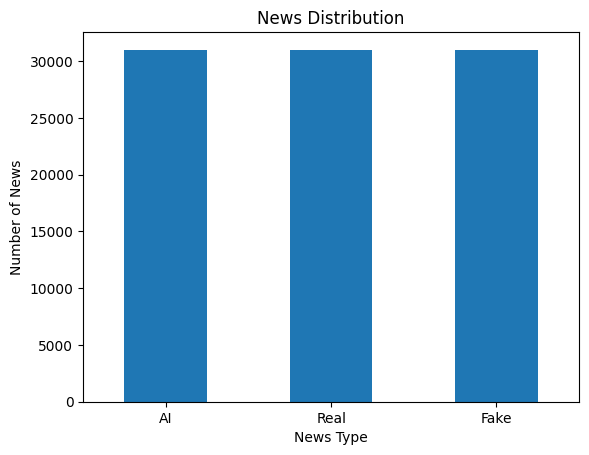

In [12]:
get_plot(df_balanced)

In [13]:
df_balanced.to_csv("../data/processed/news_balanced.csv", index=False)